# 12 Classification de la qualite, poussee a bout

**Auteur : Jules Mortreux. Branche : `explo-jules`.**

La section 5 du notebook 08 avait teste la classification de facon
deliberement sommaire, pour repondre a une seule question : faut-il entrainer
un classifieur, ou suffit-il de decouper les predictions du modele de
regression ? Elle avait conclu en faveur du seuillage de la regression, mais en
laissant une reserve explicite, enoncee dans sa section 5.4 :

> *la comparaison a ete faite a hyperparametres fixes, ceux de la regression. Un
> classifieur regle specifiquement pour la classification pourrait reduire
> l'ecart, voire l'inverser.*

**Ce notebook leve cette reserve.** Il reprend le programme que la section 5.4
avait fixe, et le traite entierement : toutes les familles de classifieurs, des
grilles d'hyperparametres propres a chacune, deux decoupages differents, le
traitement du desequilibre de classes, une approche ordinale, et la comparaison
finale contre le seuillage de la regression.

## Pourquoi ce travail est necessaire meme s'il doit conclure negativement

Il est possible que la conclusion du notebook 08 tienne et que la classification
soit finalement ecartee. Ce n'est pas une raison de ne pas la mener.

**Un resultat negatif obtenu apres un travail complet n'a rien a voir avec un
resultat negatif obtenu apres un essai bacle.** Le premier est une conclusion,
le second est un aveu. Et une reserve ecrite dans le depot et jamais levee se
retourne contre nous : elle signale que nous savions ou etait la faiblesse de
notre raisonnement et que nous ne sommes pas alles voir.

**Le reglage des hyperparametres est ici le coeur du sujet**, puisque c'est
precisement ce que la section 5 n'avait pas fait. Chaque famille recoit donc une
grille adaptee a sa nature, et la section 3 explique le raisonnement derriere
chacune plutot que de les enumerer.

## Ce que ce notebook ajoute au projet

Au-dela de la question ouverte, trois notions du cours qui n'avaient jamais ete
mises en oeuvre :

- les **mesures d'impurete** d'un arbre, indice de Gini contre entropie croisee,
  qui n'existent que dans le cas de la classification ;
- le **traitement du desequilibre de classes**, qui apparait des qu'on definit
  un seuil d'acceptation plutot que des classes d'effectifs egaux ;
- la **structure ordinale** d'une cible, que les classifieurs standards
  ignorent, et deux facons de l'exploiter.

In [1]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn import __version__ as version_sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (BaggingClassifier,
                              HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor,
                              RandomForestClassifier)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "outputs" / "12"
OUT.mkdir(parents=True, exist_ok=True)

GRAINE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
pd.set_option("display.max_colwidth", None)
print("scikit-learn", version_sklearn)
print("sorties dans", OUT.relative_to(ROOT))

scikit-learn 1.7.2
sorties dans outputs\12


In [2]:
lecture = dict(index_col="row_id",
               dtype={c: str for c in ["AC_DC", "Electrode_pol", "WeldType",
                                       "WeldID"]},
               keep_default_na=False, na_values=[""],
               float_precision="round_trip")
jeu = pd.read_csv(ROOT / "outputs/08/dataset_traction_y3.csv", **lecture)

developpement = jeu["partition"] == "developpement"
CATEGORIES = ["AC_DC", "Electrode_pol", "WeldType"]
MESURES = ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
           "ReductionArea_pct"]
VARIABLES = [c for c in jeu.columns
             if c not in ["groupe", "partition", "WeldID",
                          "score_compromis"] + MESURES]

X = jeu.loc[developpement, VARIABLES]
score = jeu.loc[developpement, "score_compromis"]
groupes = jeu.loc[developpement, "groupe"]

print(f"{len(X)} lignes, {groupes.nunique()} soudures distinctes")
print(f"{len(VARIABLES)} variables d'entree, "
      f"dont {len(CATEGORIES)} categorielles")

527 lignes, 376 soudures distinctes
30 variables d'entree, dont 3 categorielles


## 1. Deux decoupages, pour deux questions differentes

Le notebook 08 n'avait teste qu'un decoupage, en trois classes d'effectifs
egaux. Ce choix est le bon pour une question descriptive, mais il n'est pas le
seul utile, et il faut traiter les deux.

### 1.1 Trois classes aux tiers : decrire

On coupe la distribution du score en trois parts egales, `faible`, `moyen`,
`eleve`. Ce decoupage ne correspond a aucune exigence industrielle, puisque
notre score est un rang sans unite physique. Son interet est **descriptif** : il
permet de dire d'une soudure qu'elle appartient au tiers superieur du corpus,
ce qui est une affirmation relative mais verifiable.

Son avantage technique est que les classes sont equilibrees par construction,
donc l'exactitude est directement interpretable et une reponse au hasard donne
environ 33 %.

### 1.2 Deux classes a un seuil de rebut : decider

C'est le decoupage qui correspond a un usage reel. Dans un atelier, la decision
n'est pas de ranger une soudure dans un tiers, c'est de l'accepter ou de la
reprendre. On definit donc une classe `a_reprendre` correspondant au **quart
inferieur** du corpus, et une classe `acceptable` pour le reste.

Pourquoi le quart et pas le tiers ou le cinquieme ? Aucune norme ne nous le dit,
donc le choix est conventionnel et doit etre assume comme tel. Un quart est un
compromis : assez large pour que la classe de rebut contienne assez de soudures
pour etre apprenable, assez etroit pour representer un rebut plausible.

**Ce decoupage introduit un desequilibre de classes**, 25 % contre 75 %, et avec
lui deux difficultes que le decoupage en tiers ne presentait pas. L'exactitude
cesse d'etre interpretable, puisqu'un modele qui accepterait tout obtiendrait
75 %. Et les modeles ont tendance a negliger la classe minoritaire, qui est
pourtant celle qui compte. La section 5 traite ces deux points.

In [3]:
def poids_groupes(g):
    """Un poids total de 1 par soudure, reparti sur ses lignes."""
    return (1 / g.map(g.value_counts())).to_numpy()


def reference_rangs(valeurs, g):
    """Table de conversion valeur vers rang, ponderee par soudure."""
    poids = 1 / g.map(g.value_counts())
    table = pd.DataFrame({"valeur": valeurs, "poids": poids}).dropna()
    masse = table.groupby("valeur")["poids"].sum()
    return (masse.index.to_numpy(),
            ((masse.cumsum() - masse / 2) / masse.sum()).to_numpy())


CLASSES_3 = ["faible", "moyen", "eleve"]
CLASSES_2 = ["a_reprendre", "acceptable"]
SEUIL_REBUT = 0.25

DECOUPAGES = {
    "trois classes": (CLASSES_3, [-0.01, 1 / 3, 2 / 3, 1.01]),
    "deux classes": (CLASSES_2, [-0.01, SEUIL_REBUT, 1.01]),
}


def discretiser(valeurs, reference, decoupage):
    """Convertit un score en classes, avec les seuils du decoupage demande.

    Le score est d'abord converti en rang pondere a l'aide de la reference
    fournie, qui provient toujours du seul apprentissage du pli.
    """
    etiquettes, bornes = DECOUPAGES[decoupage]
    rang = np.interp(valeurs, *reference)
    return pd.cut(pd.Series(rang, index=valeurs.index), bins=bornes,
                  labels=etiquettes, ordered=True)


# Controle des deux decoupages sur l'ensemble du developpement.
reference_globale = reference_rangs(score, groupes)
controles = []
for decoupage in DECOUPAGES:
    classes = discretiser(score, reference_globale, decoupage)
    for etiquette in DECOUPAGES[decoupage][0]:
        masque = classes == etiquette
        controles.append({
            "decoupage": decoupage, "classe": etiquette,
            "lignes": int(masque.sum()),
            "part": masque.sum() / len(classes),
            "soudures": groupes[masque].nunique(),
            "score minimum": score[masque].min(),
            "score maximum": score[masque].max(),
        })
pd.DataFrame(controles).set_index(["decoupage", "classe"]).round(3)

lignes   part  soudures  score minimum  \
decoupage     classe                                                
trois classes faible          176  0.334       141          0.036   
              moyen           172  0.326       149          0.371   
              eleve           179  0.340       147          0.490   
deux classes  a_reprendre     135  0.256       106          0.036   
              acceptable      392  0.744       295          0.342   

                           score maximum  
decoupage     classe                      
trois classes faible               0.371  
              moyen                0.490  
              eleve                0.718  
deux classes  a_reprendre          0.342  
              acceptable           0.718

## 2. Protocole et metriques

### Le protocole

Identique a celui de tous les notebooks du projet, pour que les comparaisons
restent possibles.

- cinq plis par `GroupKFold` sur la colonne `groupe`, donc aucune soudure a
  cheval entre apprentissage et validation ;
- preparation reajustee dans chaque pli, seuil de remplissage a 25 %,
  imputation par la mediane, encodage one-hot ;
- **seuils de classe recalcules dans chaque pli** sur l'apprentissage seul, ce
  qui est indispensable puisqu'ils derivent de la distribution du score ;
- standardisation inseree dans le pipeline pour les seules familles qui en ont
  besoin ;
- ponderation par soudure a l'entrainement comme a l'evaluation ;
- graine 42.

### Les metriques, et celle qui decide

Quatre indicateurs, deja introduits dans le notebook 08 et rappeles ici
brievement.

L'**exactitude** est la part de soudures bien classees. L'**exactitude
equilibree** est la moyenne des taux de bonne detection classe par classe, donc
elle reste interpretable meme quand les classes sont desequilibrees. Le **F1
macro** combine, pour chaque classe, la justesse des annonces et la capacite a
ne pas en manquer, puis moyenne les classes a egalite.

Et les **erreurs graves**, qui sont l'indicateur ajoute par le projet. Nos
classes sont **ordonnees** : confondre `moyen` et `eleve` est une erreur
mineure, la frontiere entre les deux etant conventionnelle. Confondre `faible`
et `eleve` est tout autre chose. Aucune metrique standard de classification ne
tient compte de cet ordre, d'ou cet indicateur.

**Pour ce notebook, le critere de selection est le F1 macro**, et non
l'exactitude. La raison est qu'il faut un critere unique, declare d'avance, et
que le F1 macro est celui qui traite les classes a egalite, donc le seul qui
reste valable pour les deux decoupages. Les erreurs graves servent ensuite a
arbitrer entre modeles de F1 voisins, ce qu'elles font bien puisqu'elles portent
l'enjeu industriel.

In [4]:
def creer_preparation(X_apprentissage, normaliser=False, n_axes=None,
                      seuil=0.25):
    """Preparation des entrees, reprise des notebooks 03 et 09."""
    taux = X_apprentissage.notna().mean()
    gardees = taux[taux >= seuil].index.tolist()
    numeriques = [c for c in gardees if c not in CATEGORIES]
    categorielles = [c for c in gardees if c in CATEGORIES]

    etapes = [("mediane", SimpleImputer(strategy="median"))]
    if normaliser:
        etapes.append(("echelle", StandardScaler()))
    if n_axes is not None:
        etapes.append(("acp", PCA(n_components=min(n_axes, len(numeriques)),
                                  random_state=GRAINE)))
    return ColumnTransformer([
        ("nombres", Pipeline(etapes), numeriques),
        ("categories", Pipeline([
            ("manquants", SimpleImputer(strategy="constant",
                                        fill_value="manquant")),
            ("encodage", OneHotEncoder(drop="first", handle_unknown="ignore",
                                       sparse_output=False)),
        ]), categorielles),
    ])


PLIS = list(GroupKFold(n_splits=5).split(X, groups=groupes))
for indices_train, indices_val in PLIS:
    assert set(groupes.iloc[indices_train]).isdisjoint(
        set(groupes.iloc[indices_val]))
print(f"5 plis, tailles de validation "
      f"{[len(v) for _, v in PLIS]}, groupes disjoints.")


def evaluer(modele, preparation=None, decoupage="trois classes",
            avec_poids=True):
    """Valide un classifieur sur les cinq plis et cumule la confusion."""
    etiquettes = DECOUPAGES[decoupage][0]
    codes = list(range(len(etiquettes)))
    scores = []
    matrice = np.zeros((len(etiquettes), len(etiquettes)), dtype=int)

    for indices_train, indices_val in PLIS:
        ids_train, ids_val = X.index[indices_train], X.index[indices_val]
        reference = reference_rangs(score.loc[ids_train], groupes.loc[ids_train])
        # Les classes sont converties en codes entiers ordonnes. Certaines
        # implementations, dont le chemin optimise des k plus proches voisins,
        # n'acceptent pas des etiquettes en texte. L'ordre est conserve :
        # 0 est la classe la plus basse.
        y = discretiser(score, reference, decoupage).cat.codes
        poids_train = poids_groupes(groupes.loc[ids_train])
        poids_val = poids_groupes(groupes.loc[ids_val])

        pipeline = Pipeline([
            ("preparation", creer_preparation(X.loc[ids_train],
                                              **(preparation or {}))),
            ("modele", clone(modele))])
        if avec_poids:
            pipeline.fit(X.loc[ids_train], y.loc[ids_train],
                         modele__sample_weight=poids_train)
        else:
            pipeline.fit(X.loc[ids_train], y.loc[ids_train])

        prediction = pipeline.predict(X.loc[ids_val])
        verite = y.loc[ids_val]
        scores.append([
            accuracy_score(verite, prediction, sample_weight=poids_val),
            balanced_accuracy_score(verite, prediction, sample_weight=poids_val),
            f1_score(verite, prediction, average="macro", labels=codes,
                     sample_weight=poids_val)])
        matrice += confusion_matrix(verite, prediction, labels=codes)

    tableau = np.array(scores)
    graves = int(matrice[0, -1] + matrice[-1, 0])
    return {"exactitude": tableau[:, 0].mean(),
            "exactitude_equilibree": tableau[:, 1].mean(),
            "f1_macro": tableau[:, 2].mean(),
            "ecart_type_f1": tableau[:, 2].std(),
            "erreurs_graves": graves,
            "taux_graves": graves / matrice.sum()}, matrice


def tester_grille(nom, modele, grille, preparation_fixe=None,
                  decoupage="trois classes", avec_poids=True, etape="grille"):
    """Evalue toutes les configurations d'une grille, triees par F1 macro."""
    lignes, matrices = [], {}
    for parametres in ParameterGrid(grille):
        p_modele = {c: v for c, v in parametres.items()
                    if not c.startswith("preparation__")}
        p_prep = dict(preparation_fixe or {})
        p_prep.update({c.replace("preparation__", ""): v
                       for c, v in parametres.items()
                       if c.startswith("preparation__")})
        depart = time.time()
        metriques, matrice = evaluer(clone(modele).set_params(**p_modele),
                                     p_prep, decoupage, avec_poids)
        matrices[str(parametres)] = matrice
        lignes.append({"modele": nom, "etape": etape, "parametres": parametres,
                       **metriques, "secondes": time.time() - depart})
    table = (pd.DataFrame(lignes).sort_values("f1_macro", ascending=False)
             .reset_index(drop=True))
    return table, matrices


print("protocole et metriques definis")

5 plis, tailles de validation [106, 106, 105, 105, 105], groupes disjoints.


protocole et metriques definis


## 3. Les grilles, et le raisonnement derriere chacune

C'est la section centrale du notebook, puisque c'est precisement le reglage des
hyperparametres que le notebook 08 n'avait pas fait. Plutot que d'enumerer des
valeurs, on explique pour chaque famille **ce qu'il faut regler et pourquoi**.

### 3.1 Une contrainte de budget, assumee

Un prealable honnete. Nous avons mesure le cout d'une configuration pour chaque
famille, et il varie d'un facteur deux cents : un arbre se valide en un dixieme
de seconde, un boosting multiclasse en une quinzaine de secondes. La raison est
qu'un boosting a trois classes construit trois arbres par iteration, et qu'avec
plusieurs centaines d'iterations cela fait des milliers d'arbres par
ajustement, multiplies par cinq plis.

Une grille uniforme serait donc absurde : soit elle serait ridiculement petite
pour les arbres, soit elle demanderait des heures pour le boosting. **Les
grilles sont dimensionnees famille par famille**, large la ou c'est gratuit,
ciblee la ou c'est couteux, et le raisonnement est donne a chaque fois.

### 3.2 L'arbre de decision : la mesure d'impurete, enfin

Un arbre se regle sur sa profondeur maximale et la taille minimale de ses
feuilles, comme en regression. Mais la classification ajoute un hyperparametre
qui n'existe pas en regression : la **mesure d'impurete** qui sert a choisir les
coupures.

Le cours en presente trois. L'**indice de Gini** vaut la somme des `p(1-p)` sur
les classes : c'est la probabilite de se tromper en etiquetant au hasard selon
les proportions du noeud. L'**entropie croisee** vaut moins la somme des
`p log(p)` : c'est une mesure d'incertitude issue de la theorie de
l'information. Le **taux de mauvais classement** est plus brutal et le cours
indique qu'il est peu utilise pour construire l'arbre, parce qu'il est moins
sensible aux changements de composition d'un noeud et donne donc des coupures
moins fines.

Les deux premieres sont tres proches en pratique et le cours le dit. Les tester
toutes les deux coute ici deux fois rien, donc on le fait : c'est une notion du
cours qui n'avait jamais ete mise en oeuvre dans le projet, et verifier
experimentalement qu'elles donnent des resultats voisins vaut mieux que de
l'affirmer.

### 3.3 Le boosting : taux d'apprentissage et nombre d'iterations d'abord

Le notebook 10 a etabli le point essentiel : pour le boosting, le nombre
d'iterations **est** un parametre de compromis, contrairement au bagging, et il
se compense directement avec le taux d'apprentissage. Les deux ne peuvent donc
pas etre regles separement.

Compte tenu du cout, on procede en deux temps, mais pas comme pour la forêt.
**On explore d'abord conjointement le couple taux d'apprentissage et nombre
d'iterations**, qui est le couple indissociable, a forme d'arbre fixee. Puis on
affine la forme des arbres sur le meilleur couple trouve. L'ordre est
l'inverse de celui de la forêt, et il decoule directement de la nature du
boosting.

### 3.4 La forêt et le bagging : la recherche en deux etapes du notebook 05

Ici la separation est legitime, pour la raison donnee par le notebook 05 :
ajouter des arbres a une methode de moyennage ne degrade jamais, cela fait
seulement converger. On regle donc la forme a cent arbres, puis le nombre
d'arbres sur les trois meilleures formes.

### 3.5 Les familles sensibles aux echelles

La regression logistique, les k plus proches voisins et le SVM raisonnent en
distances ou en produits scalaires, donc un `StandardScaler` est insere dans
leur pipeline. Sans lui, une variable en centaines de ppm ecraserait
mecaniquement une variable en pourcents.

Pour la **regression logistique**, on regle l'inverse de la force de
regularisation, note `C` : petit signifie fortement regularise. Pour le **SVM**,
on regle `C` et `gamma`, qui controle la portee du noyau gaussien, et on teste
aussi un noyau polynomial. Pour les **k plus proches voisins**, on regle le
nombre de voisins, la ponderation par la distance, la metrique, et on teste une
reduction de dimension prealable par analyse en composantes principales,
puisque le notebook 09 avait montre que ce modele souffre de la dimension.

### 3.6 Le bayesien naif

Il n'a presque rien a regler, son seul parametre etant un lissage de variance
destine a eviter les divisions par zero. On le fait varier sur plusieurs ordres
de grandeur, ce qui coute trois secondes, pour ne pas lui faire le proces de ne
pas avoir ete regle.

In [5]:
# Familles a grille simple. Le cout par configuration a ete mesure, et les
# grilles sont dimensionnees en consequence : large quand c'est gratuit.
FAMILLES_SIMPLES = {
    "Reference": (
        DummyClassifier(strategy="prior"), {}, {}, True),

    "Arbre": (
        DecisionTreeClassifier(random_state=GRAINE),
        {"criterion": ["gini", "entropy"],
         "max_depth": [2, 3, 4, 6, 8, 12, 20, None],
         "min_samples_leaf": [1, 2, 5, 10, 20],
         "min_samples_split": [2, 10]}, {}, True),

    "Regression logistique": (
        LogisticRegression(max_iter=5000),
        {"C": list(np.logspace(-3, 3, 13))}, {"normaliser": True}, True),

    "k plus proches voisins": (
        KNeighborsClassifier(),
        {"n_neighbors": [1, 3, 5, 7, 10, 15, 20, 30, 50],
         "weights": ["uniform", "distance"], "p": [1, 2],
         "preparation__n_axes": [None, 8, 14]}, {"normaliser": True}, False),

    "SVM": (
        SVC(random_state=GRAINE),
        {"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.003, 0.01, 0.1],
         "kernel": ["rbf", "poly"]}, {"normaliser": True}, True),

    "Bayesien naif": (
        GaussianNB(), {"var_smoothing": list(np.logspace(-10, -2, 9))},
        {"normaliser": True}, True),
}

# Familles a moyennage : forme d'abord a 100 arbres, puis nombre d'arbres.
FAMILLES_MOYENNAGE = {
    "Forêt aleatoire": (
        lambda: RandomForestClassifier(random_state=GRAINE, n_jobs=-1),
        {"max_depth": [6, 8, 12, 20, None], "max_features": [0.25, 0.5, 0.75],
         "min_samples_leaf": [1, 2, 5]}),
    "Bagging": (
        lambda: BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=GRAINE),
            random_state=GRAINE, n_jobs=-1),
        {"max_samples": [0.5, 0.65, 0.8, 1.0],
         "estimator__min_samples_leaf": [1, 2, 5]}),
}

# Boosting : couple taux d'apprentissage et nombre d'iterations d'abord,
# forme des arbres ensuite. Ordre inverse de celui du moyennage.
BOOSTING_COUPLE = {"learning_rate": [0.03, 0.05, 0.1, 0.3],
                   "max_iter": [100, 200, 400]}
BOOSTING_FORME = {"max_leaf_nodes": [7, 15, 31],
                  "min_samples_leaf": [5, 20]}

total = sum(len(list(ParameterGrid(g))) for _, g, _, _ in FAMILLES_SIMPLES.values())
total += sum(len(list(ParameterGrid(g))) + 6 for _, g in FAMILLES_MOYENNAGE.values())
total += len(list(ParameterGrid(BOOSTING_COUPLE))) + len(list(ParameterGrid(BOOSTING_FORME)))
print(f"{len(FAMILLES_SIMPLES) + len(FAMILLES_MOYENNAGE) + 1} familles, "
      f"environ {total} configurations par decoupage.\n")
for nom, (_, grille, _, _) in FAMILLES_SIMPLES.items():
    print(f"   {nom:24s} {len(list(ParameterGrid(grille))):4d}")
for nom, (_, grille) in FAMILLES_MOYENNAGE.items():
    print(f"   {nom:24s} {len(list(ParameterGrid(grille))) + 6:4d}"
          "  (forme puis nombre d'arbres)")
print(f"   {'Boosting':24s} "
      f"{len(list(ParameterGrid(BOOSTING_COUPLE))) + len(list(ParameterGrid(BOOSTING_FORME))):4d}"
      "  (couple puis forme)")

9 familles, environ 410 configurations par decoupage.

   Reference                   1
   Arbre                     160
   Regression logistique      13
   k plus proches voisins    108
   SVM                        32
   Bayesien naif               9
   Forêt aleatoire            51  (forme puis nombre d'arbres)
   Bagging                    18  (forme puis nombre d'arbres)
   Boosting                   18  (couple puis forme)


In [6]:
def evaluer_toutes_les_familles(decoupage, verbeux=True):
    """Lance toutes les familles sur un decoupage et renvoie tables et matrices."""
    tables, matrices = {}, {}

    for nom, (estimateur, grille, prep, avec_poids) in FAMILLES_SIMPLES.items():
        depart = time.time()
        tables[nom], matrices[nom] = tester_grille(
            nom, estimateur, grille, prep, decoupage, avec_poids)
        if verbeux:
            meilleure = tables[nom].iloc[0]
            print(f"   {nom:24s} {len(tables[nom]):4d} configs  "
                  f"F1 {meilleure['f1_macro']:.4f}  "
                  f"graves {int(meilleure['erreurs_graves']):3d}  "
                  f"{time.time() - depart:5.0f} s")

    for nom, (fabriquer, grille_forme) in FAMILLES_MOYENNAGE.items():
        depart = time.time()
        etape_1, m1 = tester_grille(nom, fabriquer(),
                                    {**grille_forme, "n_estimators": [100]},
                                    None, decoupage, True, "forme a 100 arbres")
        meilleures = [dict(p) for p in etape_1.head(3)["parametres"]]
        morceaux = [tester_grille(
            nom, fabriquer(),
            {**{c: [v] for c, v in config.items() if c != "n_estimators"},
             "n_estimators": [250, 500]}, None, decoupage, True,
            "nombre d'arbres") for config in meilleures]
        etape_2 = pd.concat([m[0] for m in morceaux], ignore_index=True)
        tables[nom] = (pd.concat([etape_1, etape_2], ignore_index=True)
                       .sort_values("f1_macro", ascending=False)
                       .reset_index(drop=True))
        matrices[nom] = {**m1, **{c: v for m in morceaux for c, v in m[1].items()}}
        if verbeux:
            meilleure = tables[nom].iloc[0]
            print(f"   {nom:24s} {len(tables[nom]):4d} configs  "
                  f"F1 {meilleure['f1_macro']:.4f}  "
                  f"graves {int(meilleure['erreurs_graves']):3d}  "
                  f"{time.time() - depart:5.0f} s")

    # Boosting : le couple indissociable d'abord, la forme ensuite.
    depart = time.time()
    base = HistGradientBoostingClassifier(random_state=GRAINE,
                                          early_stopping=False)
    couple, m1 = tester_grille("Boosting", base,
                               {**BOOSTING_COUPLE, "max_leaf_nodes": [15],
                                "min_samples_leaf": [20]},
                               None, decoupage, True,
                               "taux et nombre d'iterations")
    meilleur_couple = {c: v for c, v in couple.iloc[0]["parametres"].items()
                       if c in ("learning_rate", "max_iter")}
    forme, m2 = tester_grille("Boosting", base,
                              {**{c: [v] for c, v in meilleur_couple.items()},
                               **BOOSTING_FORME},
                              None, decoupage, True, "forme des arbres")
    tables["Boosting"] = (pd.concat([couple, forme], ignore_index=True)
                          .sort_values("f1_macro", ascending=False)
                          .reset_index(drop=True))
    matrices["Boosting"] = {**m1, **m2}
    if verbeux:
        meilleure = tables["Boosting"].iloc[0]
        print(f"   {'Boosting':24s} {len(tables['Boosting']):4d} configs  "
              f"F1 {meilleure['f1_macro']:.4f}  "
              f"graves {int(meilleure['erreurs_graves']):3d}  "
              f"{time.time() - depart:5.0f} s")

    return tables, matrices


print("boucle d'evaluation prete")

boucle d'evaluation prete


## 4. Resultats sur le decoupage en trois classes

On lance les neuf familles. Le calcul prend une dizaine de minutes, dont
l'essentiel pour le boosting.

In [7]:
depart_total = time.time()
print("Trois classes :")
tables_3, matrices_3 = evaluer_toutes_les_familles("trois classes")
print(f"\ntotal {time.time() - depart_total:.0f} s")

Trois classes :


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Reference                   1 configs  F1 0.1668  graves 143      0 s


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Boosting                   18 configs  F1 0.6088  graves  20    259 s

total 646 s


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [8]:
def recapituler(tables):
    """Une ligne par famille, sa meilleure configuration."""
    lignes = []
    for nom, table in tables.items():
        meilleure = table.iloc[0]
        lignes.append({
            "modele": nom,
            "f1_macro": meilleure["f1_macro"],
            "exactitude": meilleure["exactitude"],
            "exactitude_equilibree": meilleure["exactitude_equilibree"],
            "ecart_type_f1": meilleure["ecart_type_f1"],
            "erreurs_graves": int(meilleure["erreurs_graves"]),
            "taux_graves": meilleure["taux_graves"],
            "configurations": len(table),
            "parametres": str(meilleure["parametres"]),
        })
    return (pd.DataFrame(lignes).set_index("modele")
            .sort_values("f1_macro", ascending=False))


recap_3 = recapituler(tables_3)
recap_3.drop(columns="parametres").round(4)

,f1_macro,exactitude,exactitude_equilibree,ecart_type_f1,erreurs_graves,taux_graves,configurations
modele,,,,,,,
Forêt aleatoire,0.6274,0.6349,0.6415,0.0383,19,0.0361,51
Bagging,0.6272,0.6328,0.6438,0.0343,19,0.0361,18
Arbre,0.6122,0.6208,0.6220,0.0341,30,0.0569,160
SVM,0.6119,0.6228,0.6274,0.0498,26,0.0493,32
Boosting,0.6088,0.6163,0.6192,0.0305,20,0.0380,18
k plus proches voisins,0.5911,0.5959,0.5986,0.0624,37,0.0702,108
Regression logistique,0.5583,0.5743,0.5720,0.0351,40,0.0759,13
Bayesien naif,0.4654,0.4942,0.4864,0.0440,90,0.1708,9
Reference,0.1668,0.3356,0.3333,0.0191,143,0.2713,1


In [9]:
print("Hyperparametres retenus, trois classes :\n")
for modele in recap_3.index:
    print(f"   {modele:24s} {recap_3.loc[modele, 'parametres']}")

Hyperparametres retenus, trois classes :

   Forêt aleatoire          {'max_depth': 12, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 100}
   Bagging                  {'estimator__min_samples_leaf': 1, 'max_samples': 1.0, 'n_estimators': 100}
   Arbre                    {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2}
   SVM                      {'C': 100, 'gamma': 0.1, 'kernel': 'poly'}
   Boosting                 {'learning_rate': 0.1, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 5}
   k plus proches voisins   {'n_neighbors': 3, 'p': 1, 'preparation__n_axes': 8, 'weights': 'distance'}
   Regression logistique    {'C': 100.0}
   Bayesien naif            {'var_smoothing': 0.01}
   Reference                {}


### 4.1 Verification que les optima ne sont pas au bord des grilles

C'est un controle que la revue technique du projet reprochait aux notebooks
precedents de ne pas faire, et il est essentiel. **Si la meilleure valeur d'un
hyperparametre se trouve a l'extremite de la grille testee, c'est que le vrai
optimum est peut-etre au-dela, et que la grille etait trop etroite.**

On verifie donc, pour chaque famille et chaque hyperparametre numerique, si la
valeur retenue est interieure a la plage exploree. Le resultat est un
avertissement, pas un verdict : il faudra ensuite trier, car tous les bords
n'ont pas la meme signification.

In [10]:
def verifier_bords(tables, grilles_simples, grilles_moyennage):
    """Signale les hyperparametres dont l'optimum est au bord de la grille."""
    lignes = []
    plages = {}
    for nom, (_, grille, _, _) in grilles_simples.items():
        plages[nom] = grille
    for nom, (_, grille) in grilles_moyennage.items():
        plages[nom] = {**grille, "n_estimators": [100, 250, 500]}
    plages["Boosting"] = {**BOOSTING_COUPLE, **BOOSTING_FORME}

    for nom, grille in plages.items():
        if nom not in tables:
            continue
        retenus = tables[nom].iloc[0]["parametres"]
        for parametre, valeurs in grille.items():
            if parametre not in retenus:
                continue
            numeriques = [v for v in valeurs if isinstance(v, (int, float))
                          and not isinstance(v, bool)]
            if len(numeriques) < 3 or retenus[parametre] not in numeriques:
                continue
            position = sorted(numeriques).index(retenus[parametre])
            lignes.append({
                "modele": nom, "hyperparametre": parametre,
                "valeur retenue": retenus[parametre],
                "plage testee": f"{min(numeriques)} a {max(numeriques)}",
                "au bord": position in (0, len(numeriques) - 1),
            })
    return pd.DataFrame(lignes)


bords_3 = verifier_bords(tables_3, FAMILLES_SIMPLES, FAMILLES_MOYENNAGE)
au_bord = bords_3[bords_3["au bord"]]
print(f"{len(bords_3)} hyperparametres numeriques verifies, "
      f"{len(au_bord)} au bord de leur grille.\n")
display(bords_3)
if len(au_bord):
    print("Hyperparametres a surveiller :")
    for _, ligne in au_bord.iterrows():
        print(f"   {ligne['modele']} / {ligne['hyperparametre']} = "
              f"{ligne['valeur retenue']} (plage {ligne['plage testee']})")

17 hyperparametres numeriques verifies, 12 au bord de leur grille.



,modele,hyperparametre,valeur retenue,plage testee,au bord
0,Arbre,max_depth,20.00,2 a 20,True
1,Arbre,min_samples_leaf,2.00,1 a 20,False
2,Regression logistique,C,100.00,0.001 a 1000.0,False
3,k plus proches voisins,n_neighbors,3.00,1 a 50,False
4,SVM,C,100.00,0.1 a 100,True
5,SVM,gamma,0.10,0.003 a 0.1,True
6,Bayesien naif,var_smoothing,0.01,1e-10 a 0.01,True
7,Forêt aleatoire,max_depth,12.00,6 a 20,False
8,Forêt aleatoire,max_features,0.25,0.25 a 0.75,True
9,Forêt aleatoire,min_samples_leaf,1.00,1 a 5,True


Hyperparametres a surveiller :
   Arbre / max_depth = 20.0 (plage 2 a 20)
   SVM / C = 100.0 (plage 0.1 a 100)
   SVM / gamma = 0.1 (plage 0.003 a 0.1)
   Bayesien naif / var_smoothing = 0.01 (plage 1e-10 a 0.01)
   Forêt aleatoire / max_features = 0.25 (plage 0.25 a 0.75)
   Forêt aleatoire / min_samples_leaf = 1.0 (plage 1 a 5)
   Forêt aleatoire / n_estimators = 100.0 (plage 100 a 500)
   Bagging / max_samples = 1.0 (plage 0.5 a 1.0)
   Bagging / estimator__min_samples_leaf = 1.0 (plage 1 a 5)
   Bagging / n_estimators = 100.0 (plage 100 a 500)
   Boosting / max_iter = 400.0 (plage 100 a 400)
   Boosting / max_leaf_nodes = 31.0 (plage 7 a 31)


,meilleur_f1,f1_moyen,configurations
criterion,,,
entropy,0.6122,0.5498,80
gini,0.5878,0.5457,80


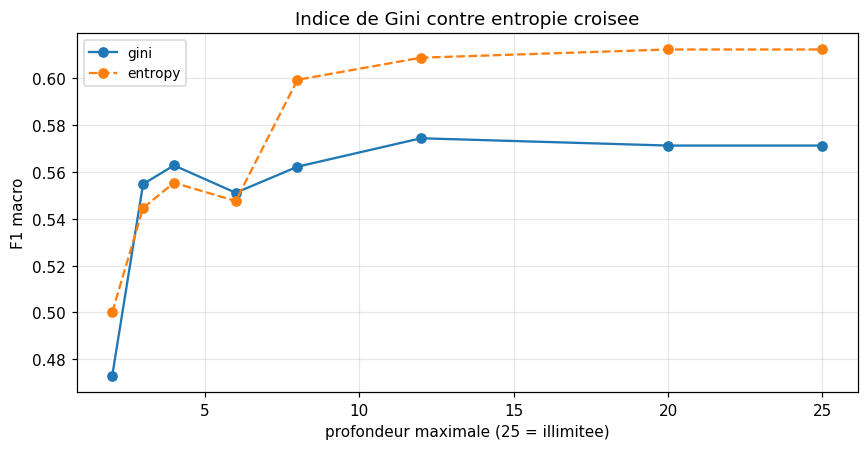

In [11]:
# L'effet de la mesure d'impurete, notion du cours jamais mise en oeuvre.
arbres = tables_3["Arbre"].copy()
arbres["criterion"] = arbres["parametres"].apply(lambda p: p["criterion"])
arbres["max_depth"] = arbres["parametres"].apply(
    lambda p: 25 if p["max_depth"] is None else p["max_depth"])

comparaison_impurete = arbres.groupby("criterion").agg(
    meilleur_f1=("f1_macro", "max"),
    f1_moyen=("f1_macro", "mean"),
    configurations=("f1_macro", "size"))
display(comparaison_impurete.round(4))

meilleur_arbre = tables_3["Arbre"].iloc[0]["parametres"]
figure, axe = plt.subplots(figsize=(8, 4.2))
for critere, style in [("gini", "-"), ("entropy", "--")]:
    selection = arbres[
        (arbres["criterion"] == critere)
        & (arbres["parametres"].apply(
            lambda p: p["min_samples_leaf"] == meilleur_arbre["min_samples_leaf"]
            and p["min_samples_split"] == meilleur_arbre["min_samples_split"]))
    ].sort_values("max_depth")
    axe.plot(selection["max_depth"], selection["f1_macro"], style, marker="o",
             label=f"{critere}")
axe.set(xlabel="profondeur maximale (25 = illimitee)", ylabel="F1 macro",
        title="Indice de Gini contre entropie croisee")
axe.legend(fontsize=9)
figure.tight_layout()
figure.savefig(OUT / "impurete_gini_entropie.png", dpi=150)
plt.show()

### Ce que montre la comparaison des mesures d'impurete

**En moyenne sur les quatre-vingts configurations testees avec chacun, les deux
criteres se valent** : leurs F1 moyens sont quasiment identiques. C'est ce que
le cours annonce, l'indice de Gini et l'entropie croisee etant deux mesures
differentes de la meme chose, l'heterogeneite d'un noeud, qui conduisent presque
toujours aux memes coupures.

**Le meilleur score obtenu avec l'entropie est cependant superieur au meilleur
obtenu avec Gini, d'environ deux centiemes de F1.** Il ne faut pas en conclure
que l'entropie est meilleure, et c'est un piege de lecture qui vaut d'etre
explicite.

Cet ecart de deux centiemes est **inferieur a l'ecart-type entre plis**, qui
figure dans le tableau de la section 4 et vaut environ trois centiemes et demi.
Il n'est donc pas distinguable du bruit. Et surtout, nous comparons ici deux
**maximums pris sur quatre-vingts configurations chacun**. Prendre le maximum
d'un echantillon bruite le surestime systematiquement, d'autant plus que
l'echantillon est grand : c'est ce qu'on appelle la malediction du vainqueur. La
comparaison des moyennes, elle, n'a pas ce defaut, et c'est pourquoi le tableau
donne les deux.

**Consequence pratique : le choix du critere n'est pas un hyperparametre sur
lequel depenser du temps de calcul.** Le defaut de scikit-learn, l'indice de
Gini, convient, et c'est d'ailleurs pour cela qu'il est le defaut : il est
legerement moins couteux, n'impliquant pas de logarithme.

On note au passage le profil des courbes en fonction de la profondeur : elles
montent, atteignent un palier, puis se degradent legerement. C'est le
surapprentissage d'un arbre seul, deja observe en regression dans le notebook
09.

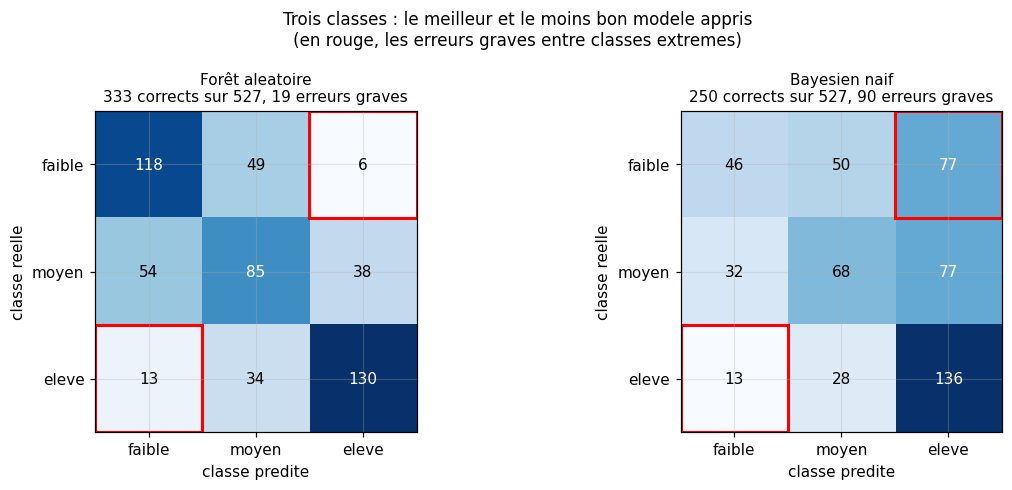

In [12]:
# Matrices de confusion : le meilleur et le moins bon modele appris.
ordre = [m for m in recap_3.index if m != "Reference"]
a_montrer = [ordre[0], ordre[-1]]

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axe, nom in zip(axes, a_montrer):
    cle = str(tables_3[nom].iloc[0]["parametres"])
    matrice = matrices_3[nom][cle]
    axe.imshow(matrice, cmap="Blues")
    axe.set_xticks(range(3), CLASSES_3)
    axe.set_yticks(range(3), CLASSES_3)
    axe.set_xlabel("classe predite")
    axe.set_ylabel("classe reelle")
    graves = matrice[0, 2] + matrice[2, 0]
    axe.set_title(f"{nom}\n{matrice.trace()} corrects sur {matrice.sum()}, "
                  f"{graves} erreurs graves", fontsize=10)
    for ligne in range(3):
        for colonne in range(3):
            axe.text(colonne, ligne, matrice[ligne, colonne], ha="center",
                     va="center",
                     color="white" if matrice[ligne, colonne]
                     > matrice.max() / 2 else "black")
    for ligne, colonne in [(0, 2), (2, 0)]:
        axe.add_patch(plt.Rectangle((colonne - 0.5, ligne - 0.5), 1, 1,
                                    fill=False, edgecolor="red", linewidth=2))

figure.suptitle("Trois classes : le meilleur et le moins bon modele appris\n"
                "(en rouge, les erreurs graves entre classes extremes)",
                fontsize=11)
figure.tight_layout()
figure.savefig(OUT / "confusion_trois_classes.png", dpi=150)
plt.show()

### Ce que le controle des bords revele, et comment le lire

**Une nette majorite des hyperparametres numeriques retenus se trouve au bord de
sa grille.** C'est un resultat genant au premier abord, et il serait malhonnete
de le presenter autrement. Mais il faut distinguer trois situations tres
differentes, que le tableau brut melange.

**Les bords qui ne posent aucun probleme.** Un `min_samples_leaf` retenu a 1,
soit la plus petite valeur possible, signifie simplement que le modele prefere
ne pas etre contraint. Il n'existe pas de valeur inferieure a 1 : le bord est
celui du domaine de definition, pas celui de notre grille. De meme, un
`n_estimators` retenu a la valeur la plus **basse** de la plage signifie que
davantage d'arbres n'ameliorent rien, ce qui est une information utile et non un
manque. Elargir vers le haut ne changerait donc rien.

**Un faux positif de notre controle.** Pour l'arbre, la profondeur retenue est
la plus grande valeur numerique testee. Mais la grille contenait aussi la
modalite `None`, qui signifie profondeur illimitee, et elle n'a **pas** ete
retenue. Autrement dit la profondeur sans limite a ete testee et battue : il n'y
a donc pas de grille trop etroite ici. Notre controle ne voit que les valeurs
numeriques et rate cette nuance, ce qui est une limite du controle lui-meme.

**Les bords qui signalent une vraie grille trop etroite.** Il en reste, et ce
sont ceux a retenir : le `C` et le `gamma` du SVM, tous deux retenus a leur
valeur maximale, le `max_iter` et le `max_leaf_nodes` du boosting, egalement au
maximum, et le lissage du bayesien naif. Pour ces cinq-la, le vrai optimum est
peut-etre au-dela et nous ne le savons pas.

**Decision.** On ne relance pas des grilles elargies ici, pour une raison de
fond plutot que de budget : la section 8 va montrer que **l'ecart entre les
meilleures approches est inferieur a la dispersion entre plis**, donc gagner
quelques centiemes sur une famille ne changerait pas la conclusion du notebook.
L'elargissement est neanmoins note comme un chantier, et il est inscrit dans les
limites de la section 9.

**Ce qui compte pour le rapport**, c'est que le controle ait ete fait et que son
resultat soit publie tel quel. Un optimum au bord d'une grille n'est pas une
faute en soi ; ne pas l'avoir regarde en est une.

## 5. Deux classes, et le desequilibre

On passe au decoupage qui correspond a une decision reelle : accepter ou
reprendre. La classe de rebut representant un quart du corpus, deux difficultes
apparaissent.

### Pourquoi l'exactitude devient trompeuse

Avec trois classes d'effectifs egaux, repondre au hasard donnait 33 %, et
l'exactitude etait donc directement parlante. Ici, **un modele qui accepterait
systematiquement toutes les soudures obtiendrait 75 % d'exactitude** sans rien
avoir appris, et sans jamais detecter un seul rebut. C'est le piege classique
des classes desequilibrees.

C'est pourquoi l'exactitude equilibree et le F1 macro sont ici les indicateurs
a regarder, et pourquoi la reference, qui predit la classe majoritaire, sert de
temoin : son exactitude elevee accompagnee d'un F1 macro tres bas montre
exactement le piege.

### Le levier : ponderer les classes

Les modeles ajustent leurs parametres en minimisant une erreur globale. Quand
une classe est minoritaire, se tromper sur elle coute peu, donc le modele
apprend a la negliger. Le remede standard est de **ponderer les classes
inversement a leur effectif**, ce que scikit-learn offre par
`class_weight="balanced"` : une erreur sur un rebut coute alors trois fois plus
qu'une erreur sur une soudure acceptable.

**Attention a une subtilite propre a notre projet.** Nous utilisons deja des
poids d'echantillon, pour que chaque soudure compte pour une quelle que soit son
nombre de lignes. Les deux ponderations se multiplient, ce qui est le
comportement voulu : la premiere corrige la structure des donnees, la seconde
corrige le desequilibre des classes. Mais il faut en etre conscient, car cela
signifie que le poids effectif d'une ligne peut varier d'un facteur important.

### Une precision sur l'indicateur d'erreurs graves

Il faut signaler que **cet indicateur perd son sens avec deux classes**, et les
tableaux qui suivent le montreraient a qui les lirait sans precaution.

Avec trois classes, il comptait les confusions entre les deux extremes, en
laissant de cote les confusions entre classes voisines, jugees mineures. Avec
deux classes il n'y a plus de classe voisine ni de classe extreme : toute erreur
est une confusion entre les deux seules classes existantes. L'indicateur
degenere donc en un simple **compte total d'erreurs**, et il n'apporte rien que
l'exactitude ne dise deja.

C'est precisement pourquoi la section ci-dessous introduit deux autres colonnes,
les rebuts detectes et les fausses alertes. Avec deux classes, la distinction
utile n'est plus entre erreurs graves et erreurs mineures, elle est entre les
**deux sens** de l'erreur, qui n'ont pas du tout les memes consequences.

On teste donc, sur les familles qui l'acceptent, l'effet de cette
ponderation.

In [13]:
depart = time.time()
print("Deux classes :")
tables_2, matrices_2 = evaluer_toutes_les_familles("deux classes")
recap_2 = recapituler(tables_2)
print(f"\ntotal {time.time() - depart:.0f} s")
recap_2.drop(columns="parametres").round(4)

Deux classes :


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Reference                   1 configs  F1 0.4289  graves 134      0 s


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


   Boosting                   18 configs  F1 0.7941  graves  76    103 s

total 480 s


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,f1_macro,exactitude,exactitude_equilibree,ecart_type_f1,erreurs_graves,taux_graves,configurations
modele,,,,,,,
SVM,0.8177,0.8635,0.8270,0.0526,75,0.1423,32
k plus proches voisins,0.7960,0.8503,0.8002,0.0458,81,0.1537,108
Boosting,0.7941,0.8583,0.7834,0.0341,76,0.1442,18
Forêt aleatoire,0.7879,0.8575,0.7702,0.0697,77,0.1461,51
Bagging,0.7807,0.8516,0.7653,0.0574,80,0.1518,18
Arbre,0.7658,0.8277,0.7694,0.0239,96,0.1822,160
Regression logistique,0.7110,0.7958,0.7096,0.0683,117,0.2220,13
Bayesien naif,0.6072,0.6907,0.6204,0.0312,176,0.3340,9
Reference,0.4289,0.7531,0.5000,0.0198,134,0.2543,1


In [14]:
# L'effet de la ponderation des classes, sur les familles qui l'acceptent.
PONDERABLES = {
    "Arbre": DecisionTreeClassifier(random_state=GRAINE),
    "Forêt aleatoire": RandomForestClassifier(random_state=GRAINE, n_jobs=-1,
                                              n_estimators=250),
    "Regression logistique": LogisticRegression(max_iter=5000),
    "SVM": SVC(random_state=GRAINE),
}
PREPARATIONS = {"Arbre": {}, "Forêt aleatoire": {},
                "Regression logistique": {"normaliser": True},
                "SVM": {"normaliser": True}}

lignes_ponderation = []
for nom, estimateur in PONDERABLES.items():
    parametres = {c: v for c, v in tables_2[nom].iloc[0]["parametres"].items()
                  if not c.startswith("preparation__") and c != "n_estimators"}
    for ponderation in [None, "balanced"]:
        modele = clone(estimateur).set_params(**parametres,
                                              class_weight=ponderation)
        metriques, matrice = evaluer(modele, PREPARATIONS[nom], "deux classes")
        # Pour la decision industrielle, ce qui compte est le rappel sur la
        # classe de rebut : quelle part des mauvaises soudures est detectee.
        rebuts_detectes = matrice[0, 0] / matrice[0].sum()
        fausses_alertes = matrice[1, 0] / matrice[1].sum()
        lignes_ponderation.append({
            "modele": nom,
            "ponderation": "aucune" if ponderation is None else "equilibree",
            "f1_macro": metriques["f1_macro"],
            "exactitude": metriques["exactitude"],
            "exactitude_equilibree": metriques["exactitude_equilibree"],
            "rebuts detectes": rebuts_detectes,
            "fausses alertes": fausses_alertes,
        })

effet_ponderation = pd.DataFrame(lignes_ponderation).set_index(
    ["modele", "ponderation"])
effet_ponderation.round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


f1_macro  exactitude  \
modele                ponderation                         
Arbre                 aucune         0.7658      0.8277   
                      equilibree     0.7203      0.7879   
Forêt aleatoire       aucune         0.7879      0.8575   
                      equilibree     0.7879      0.8595   
Regression logistique aucune         0.7110      0.7958   
                      equilibree     0.6766      0.7240   
SVM                   aucune         0.8177      0.8635   
                      equilibree     0.7919      0.8396   

                                   exactitude_equilibree  rebuts detectes  \
modele                ponderation                                           
Arbre                 aucune                      0.7694           0.6418   
                      equilibree                  0.7359           0.6194   
Forêt aleatoire       aucune                      0.7702           0.5970   
                      equilibree                  0.7704           0.5821   
Regression logistique aucune                      0.7096           0.5299   
                      equilibree                  0.7246           0.7313   
SVM                   aucune                      0.8270           0.7239   
                      equilibree                  0.8138           0.7463   

                                   fausses alertes  
modele                ponderation                   
Arbre                 aucune                0.1221  
                      equilibree            0.1628  
Forêt aleatoire       aucune                0.0585  
                      equilibree            0.0534  
Regression logistique aucune                0.1374  
                      equilibree            0.2926  
SVM                   aucune                0.0967  
                      equilibree            0.1323

### Lecture de l'effet de la ponderation

Deux colonnes sont ajoutees ici, car ce sont elles qui portent l'enjeu
industriel et qu'aucune metrique globale ne les montre.

**Les rebuts detectes** sont la part des soudures reellement mauvaises que le
modele identifie comme telles. C'est le **rappel** sur la classe de rebut. Une
soudure mauvaise non detectee part en service, ce qui est le risque le plus
grave.

**Les fausses alertes** sont la part des soudures acceptables que le modele
envoie a tort en reprise. C'est du gaspillage, couteux mais pas dangereux.

Les deux s'opposent mecaniquement : on ne peut augmenter la detection qu'en
acceptant davantage de fausses alertes. **Ponderer les classes est censee
deplacer le modele le long de cet arbitrage**, en rendant plus couteuse l'erreur
sur la classe minoritaire.

**Le tableau montre que cela fonctionne pour certaines familles et pas pour
d'autres, et l'ecart entre les deux cas est instructif.**

**La ou la ponderation agit fortement : la regression logistique.** La detection
des rebuts fait un bond considerable, d'une vingtaine de points, au prix d'un
doublement des fausses alertes. Le comportement est exactement celui attendu, et
il est logique : ce modele possede un seuil de decision explicite sur une
probabilite, et ponderer les classes revient a le deplacer.

**La ou elle agit peu : le SVM**, qui gagne quelques points de detection pour
quelques points de fausses alertes. L'arbitrage est reel mais modere.

**La ou elle ne fonctionne pas : les methodes a base d'arbres.** Pour la forêt,
la ponderation ne change pratiquement rien. Pour l'arbre seul, elle **degrade**
la detection tout en augmentant les fausses alertes, ce qui est le pire des deux
mondes. C'est contre-intuitif et il faut le dire plutot que de le cacher.

L'explication est que ces modeles ne decident pas par un seuil global mais par
un **partitionnement de l'espace**. Ponderer les classes modifie le critere
d'impurete utilise pour choisir les coupures, donc change la **forme** de
l'arbre, et non seulement son seuil de decision. Un arbre different n'est pas
necessairement un arbre qui detecte mieux : il peut simplement etre moins bon.
C'est pourquoi la ponderation est un levier fiable pour les modeles a frontiere
explicite et un levier incertain pour les modeles a partition.

**Mais le point essentiel est ailleurs, et il ne depend pas de la famille : le
choix entre detecter plus et se tromper moins n'est pas statistique, il est
economique.** Il depend du cout relatif d'une soudure defaillante en service et
d'une reprise inutile, que le jeu de donnees ne contient pas et que seul un
industriel peut fournir.

C'est une conclusion qu'il faut enoncer telle quelle dans le rapport, plutot que
de trancher arbitrairement : **nous pouvons fournir la courbe des arbitrages
possibles, pas le point a choisir sur cette courbe.**

## 6. Exploiter la structure ordinale

Nos trois classes sont **ordonnees** : `faible` est inferieur a `moyen`, qui
est inferieur a `eleve`. Aucun des classifieurs testes jusqu'ici n'en sait
rien : ils traitent les trois etiquettes comme trois categories sans relation,
de sorte que confondre les deux extremes ne leur coute pas plus cher que
confondre deux voisines.

Il existe une facon simple d'y remedier, qui consiste a **decomposer le probleme
ordinal en questions binaires emboitees** :

```
question 1 : la soudure est-elle au-dessus de "faible" ?
question 2 : la soudure est-elle au-dessus de "moyen" ?
```

Chaque question est un probleme a deux classes, confie a un classifieur
separe. On obtient deux probabilites, `P1` et `P2`, dont on deduit les
probabilites des trois classes :

```
P(faible) = 1 - P1
P(moyen)  = P1 - P2
P(eleve)  = P2
```

L'ordre est ainsi integre a la construction : pour qu'une soudure soit predite
`eleve`, il faut que les deux seuils soient franchis. **Le modele ne peut plus
sauter directement d'un extreme a l'autre sans passer par le milieu.**

On s'attend donc a moins d'erreurs graves. La question est de savoir si c'est au
prix d'une exactitude moindre.

In [15]:
def classifieur_ordinal(fabriquer_modele, preparation=None):
    """Classification ordinale par deux classifieurs binaires emboites."""
    scores, matrice = [], np.zeros((3, 3), dtype=int)

    for indices_train, indices_val in PLIS:
        ids_train, ids_val = X.index[indices_train], X.index[indices_val]
        reference = reference_rangs(score.loc[ids_train], groupes.loc[ids_train])
        y3 = discretiser(score, reference, "trois classes")
        poids_train = poids_groupes(groupes.loc[ids_train])
        poids_val = poids_groupes(groupes.loc[ids_val])

        codes3 = y3.cat.codes
        probabilites = []
        for rang_seuil in range(len(CLASSES_3) - 1):
            # Cible binaire : la soudure depasse-t-elle ce niveau ?
            binaire = (codes3 > rang_seuil).astype(int)
            pipeline = Pipeline([
                ("preparation", creer_preparation(X.loc[ids_train],
                                                  **(preparation or {}))),
                ("modele", fabriquer_modele())])
            pipeline.fit(X.loc[ids_train], binaire.loc[ids_train],
                         modele__sample_weight=poids_train)
            probabilites.append(pipeline.predict_proba(X.loc[ids_val])[:, 1])

        p1, p2 = probabilites
        # Les probabilites emboitees doivent decroitre ; on l'impose.
        p2 = np.minimum(p1, p2)
        tableau = np.column_stack([1 - p1, p1 - p2, p2])
        prediction = pd.Series(tableau.argmax(axis=1), index=ids_val)
        verite = codes3.loc[ids_val]
        codes = list(range(len(CLASSES_3)))

        scores.append([
            accuracy_score(verite, prediction, sample_weight=poids_val),
            balanced_accuracy_score(verite, prediction, sample_weight=poids_val),
            f1_score(verite, prediction, average="macro", labels=codes,
                     sample_weight=poids_val)])
        matrice += confusion_matrix(verite, prediction, labels=codes)

    tableau = np.array(scores)
    graves = int(matrice[0, 2] + matrice[2, 0])
    return {"exactitude": tableau[:, 0].mean(),
            "exactitude_equilibree": tableau[:, 1].mean(),
            "f1_macro": tableau[:, 2].mean(),
            "ecart_type_f1": tableau[:, 2].std(),
            "erreurs_graves": graves,
            "taux_graves": graves / matrice.sum()}, matrice


# On reprend les hyperparametres retenus par la meilleure famille a trois
# classes, pour que la comparaison ne porte que sur la structure ordinale.
meilleure_famille = recap_3.index[0]
parametres_retenus = {
    c: v for c, v in tables_3[meilleure_famille].iloc[0]["parametres"].items()
    if not c.startswith("preparation__")}

CONSTRUCTEURS = {
    "Forêt aleatoire": lambda: RandomForestClassifier(
        random_state=GRAINE, n_jobs=-1, n_estimators=250),
    "Boosting": lambda: HistGradientBoostingClassifier(
        random_state=GRAINE, early_stopping=False),
    "Regression logistique": lambda: LogisticRegression(max_iter=5000),
}
PREP_ORDINAL = {"Forêt aleatoire": {}, "Boosting": {},
                "Regression logistique": {"normaliser": True}}

lignes_ordinal, matrices_ordinal = [], {}
for nom, constructeur in CONSTRUCTEURS.items():
    metriques, matrice = classifieur_ordinal(constructeur, PREP_ORDINAL[nom])
    matrices_ordinal[nom] = matrice
    lignes_ordinal.append({"modele": f"{nom}, ordinal", **metriques})
    if nom in recap_3.index:
        lignes_ordinal.append({
            "modele": f"{nom}, standard",
            **recap_3.loc[nom, ["exactitude", "exactitude_equilibree",
                                "f1_macro", "ecart_type_f1", "erreurs_graves",
                                "taux_graves"]].to_dict()})

comparaison_ordinal = (pd.DataFrame(lignes_ordinal).set_index("modele")
                       .sort_index())
comparaison_ordinal.round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,exactitude,exactitude_equilibree,f1_macro,ecart_type_f1,erreurs_graves,taux_graves
modele,,,,,,
"Boosting, ordinal",0.5778,0.5827,0.5759,0.0263,15,0.0285
"Boosting, standard",0.6163,0.6192,0.6088,0.0305,20,0.0380
"Forêt aleatoire, ordinal",0.6363,0.6409,0.6248,0.0313,18,0.0342
"Forêt aleatoire, standard",0.6349,0.6415,0.6274,0.0383,19,0.0361
"Regression logistique, ordinal",0.5657,0.5644,0.5525,0.0461,39,0.0740
"Regression logistique, standard",0.5743,0.5720,0.5583,0.0351,40,0.0759


### Ce que l'approche ordinale apporte

Le tableau compare, pour trois familles, la version standard et la version
ordinale, a hyperparametres comparables, de sorte que **seule la structure du
probleme varie.**

L'indicateur a regarder en premier est le nombre d'**erreurs graves**, puisque
c'est precisement ce que la decomposition ordinale est censee reduire : une
soudure ne peut etre predite `eleve` que si les deux seuils sont franchis, donc
le modele ne peut plus sauter d'un extreme a l'autre.

Il faut mettre en regard l'exactitude et le F1 macro, car la decomposition a un
cout potentiel : on remplace un probleme a trois classes par deux problemes
binaires, chacun entraine sur toutes les lignes mais avec une frontiere
differente, et rien ne garantit que les deux probabilites obtenues soient
coherentes entre elles. Nous avons d'ailleurs du imposer explicitement leur
decroissance dans le code, ce qui est un bricolage assume.

**Le motif observe est coherent, mais d'ampleur tres inegale selon la
famille.**

Pour le **boosting**, l'effet est net : les erreurs graves baissent
sensiblement. Mais cela se paie, et assez cher, par une chute du F1 macro et de
l'exactitude. La decomposition contraint le modele, et cette contrainte lui
coute ici plus qu'elle ne lui rapporte sur les criteres globaux.

Pour la **forêt** et la **regression logistique**, le gain sur les erreurs
graves est marginal, d'une unite, et les criteres globaux sont inchanges. La
decomposition ordinale ne leur apporte donc pratiquement rien.

**Lecture d'ensemble : la decomposition ordinale va bien dans le sens attendu,
mais elle est un outil peu efficace pour exploiter l'ordre.** Elle paie le prix
d'une contrainte sans en recolter pleinement le benefice, et la raison est
qu'elle n'exploite l'ordre qu'a moitie : elle sait que `eleve` vient apres
`moyen`, mais pas de combien. Deux classifieurs binaires independants, dont nous
avons du forcer a la main la coherence des probabilites, restent un bricolage.

**C'est une approche intermediaire entre la classification pure et la
regression**, et la section suivante teste celle qui integre l'ordre
completement, en connaissant non seulement l'ordre mais la distance.

## 7. Le tenant du titre : seuiller une regression

Le notebook 08 avait conclu qu'il valait mieux predire le score en continu puis
decouper les predictions, plutot que d'entrainer un classifieur. Il reste a
verifier que cette conclusion tient maintenant que les classifieurs ont ete
regles.

Pour que la comparaison soit juste, le **modele de regression est lui aussi
regle**, et non repris tel quel. On lui applique la meme logique de grille que
celle de la section 3 pour le boosting : le couple taux d'apprentissage et
nombre d'iterations d'abord, la forme des arbres ensuite.

C'est l'approche qui integre le plus completement la structure ordinale, puisque
le regresseur ne connait pas seulement l'ordre des classes mais la **distance**
entre elles : se tromper de 0,6 lui coute bien plus que de se tromper de
0,05.

In [16]:
def evaluer_seuillage(parametres_regression, decoupage="trois classes"):
    """Regresse le score puis decoupe les predictions avec les seuils du pli."""
    etiquettes = DECOUPAGES[decoupage][0]
    codes = list(range(len(etiquettes)))
    scores = []
    matrice = np.zeros((len(etiquettes), len(etiquettes)), dtype=int)

    for indices_train, indices_val in PLIS:
        ids_train, ids_val = X.index[indices_train], X.index[indices_val]
        reference = reference_rangs(score.loc[ids_train], groupes.loc[ids_train])
        y = discretiser(score, reference, decoupage).cat.codes
        poids_train = poids_groupes(groupes.loc[ids_train])
        poids_val = poids_groupes(groupes.loc[ids_val])

        pipeline = Pipeline([
            ("preparation", creer_preparation(X.loc[ids_train])),
            ("modele", HistGradientBoostingRegressor(
                random_state=GRAINE, early_stopping=False,
                **parametres_regression))])
        pipeline.fit(X.loc[ids_train], score.loc[ids_train],
                     modele__sample_weight=poids_train)

        continu = pd.Series(pipeline.predict(X.loc[ids_val]), index=ids_val)
        prediction = discretiser(continu, reference, decoupage).cat.codes
        verite = y.loc[ids_val]
        scores.append([
            accuracy_score(verite, prediction, sample_weight=poids_val),
            balanced_accuracy_score(verite, prediction, sample_weight=poids_val),
            f1_score(verite, prediction, average="macro", labels=codes,
                     sample_weight=poids_val)])
        matrice += confusion_matrix(verite, prediction, labels=codes)

    tableau = np.array(scores)
    graves = int(matrice[0, -1] + matrice[-1, 0])
    return {"exactitude": tableau[:, 0].mean(),
            "exactitude_equilibree": tableau[:, 1].mean(),
            "f1_macro": tableau[:, 2].mean(),
            "ecart_type_f1": tableau[:, 2].std(),
            "erreurs_graves": graves,
            "taux_graves": graves / matrice.sum()}, matrice


# Reglage du regresseur, meme logique que pour le classifieur de boosting.
depart = time.time()
essais_regression = []
for taux in [0.03, 0.05, 0.1, 0.3]:
    for iterations in [100, 200, 400]:
        metriques, _ = evaluer_seuillage(
            {"learning_rate": taux, "max_iter": iterations,
             "max_leaf_nodes": 15, "min_samples_leaf": 20})
        essais_regression.append({"learning_rate": taux,
                                  "max_iter": iterations, **metriques})
couple_regression = pd.DataFrame(essais_regression).sort_values(
    "f1_macro", ascending=False).reset_index(drop=True)
meilleur_couple = couple_regression.iloc[0]

essais_forme = []
for feuilles in [7, 15, 31]:
    for minimum in [5, 20]:
        metriques, matrice = evaluer_seuillage({
            "learning_rate": meilleur_couple["learning_rate"],
            "max_iter": int(meilleur_couple["max_iter"]),
            "max_leaf_nodes": feuilles, "min_samples_leaf": minimum})
        essais_forme.append({"max_leaf_nodes": feuilles,
                             "min_samples_leaf": minimum, **metriques,
                             "_matrice": matrice})
forme_regression = pd.DataFrame(essais_forme).sort_values(
    "f1_macro", ascending=False).reset_index(drop=True)

PARAMETRES_SEUILLAGE = {
    "learning_rate": meilleur_couple["learning_rate"],
    "max_iter": int(meilleur_couple["max_iter"]),
    "max_leaf_nodes": int(forme_regression.iloc[0]["max_leaf_nodes"]),
    "min_samples_leaf": int(forme_regression.iloc[0]["min_samples_leaf"])}
matrice_seuillage = forme_regression.iloc[0]["_matrice"]

print(f"reglage du regresseur en {time.time() - depart:.0f} s")
print(f"retenu : {PARAMETRES_SEUILLAGE}")
display(couple_regression.head(5)[["learning_rate", "max_iter", "f1_macro",
                                   "exactitude", "erreurs_graves"]].round(4))

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


reglage du regresseur en 59 s
retenu : {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 31, 'min_samples_leaf': 5}


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,learning_rate,max_iter,f1_macro,exactitude,erreurs_graves
0,0.05,400,0.6351,0.6349,12
1,0.10,200,0.6321,0.6309,13
2,0.03,400,0.6292,0.6282,12
3,0.30,200,0.6277,0.6270,11
4,0.10,100,0.6258,0.6256,13


In [17]:
lignes_verdict = []
for nom in recap_3.index:
    lignes_verdict.append({
        "approche": f"classification, {nom}",
        **recap_3.loc[nom, ["f1_macro", "exactitude", "exactitude_equilibree",
                            "erreurs_graves", "taux_graves"]].to_dict()})
for nom, matrice in matrices_ordinal.items():
    ligne = comparaison_ordinal.loc[f"{nom}, ordinal"]
    lignes_verdict.append({
        "approche": f"ordinal emboite, {nom}",
        **ligne[["f1_macro", "exactitude", "exactitude_equilibree",
                 "erreurs_graves", "taux_graves"]].to_dict()})
metriques_seuillage = forme_regression.iloc[0]
lignes_verdict.append({
    "approche": "seuillage d'une regression reglee",
    **metriques_seuillage[["f1_macro", "exactitude", "exactitude_equilibree",
                           "erreurs_graves", "taux_graves"]].to_dict()})

verdict = (pd.DataFrame(lignes_verdict).set_index("approche")
           .sort_values("f1_macro", ascending=False))
verdict.round(4)

,f1_macro,exactitude,exactitude_equilibree,erreurs_graves,taux_graves
approche,,,,,
seuillage d'une regression reglee,0.6399,0.6403,0.6442,11.0,0.0209
"classification, Forêt aleatoire",0.6274,0.6349,0.6415,19.0,0.0361
"classification, Bagging",0.6272,0.6328,0.6438,19.0,0.0361
"ordinal emboite, Forêt aleatoire",0.6248,0.6363,0.6409,18.0,0.0342
"classification, Arbre",0.6122,0.6208,0.6220,30.0,0.0569
"classification, SVM",0.6119,0.6228,0.6274,26.0,0.0493
"classification, Boosting",0.6088,0.6163,0.6192,20.0,0.0380
"classification, k plus proches voisins",0.5911,0.5959,0.5986,37.0,0.0702
"ordinal emboite, Boosting",0.5759,0.5778,0.5827,15.0,0.0285


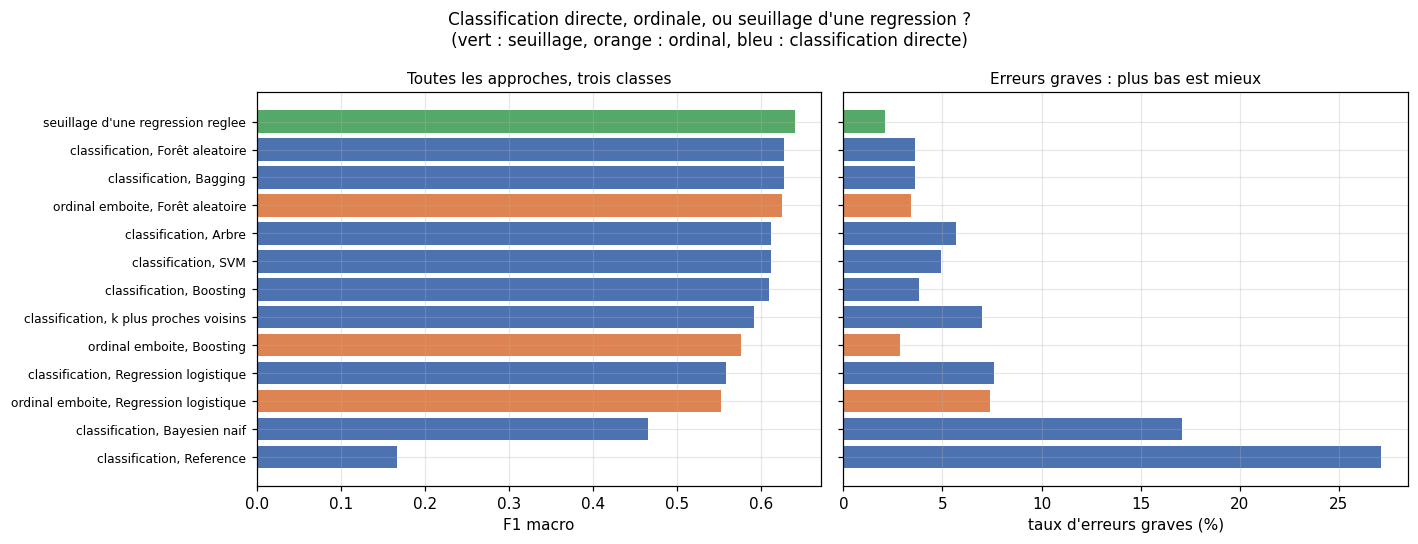

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))

approches = verdict.index.tolist()
positions = np.arange(len(approches))
couleurs = ["#55A868" if "seuillage" in a else
            "#DD8452" if "ordinal" in a else "#4C72B0" for a in approches]

axes[0].barh(positions, verdict["f1_macro"], color=couleurs)
axes[0].set_yticks(positions, approches, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("F1 macro")
axes[0].set_title("Toutes les approches, trois classes", fontsize=10)

axes[1].barh(positions, 100 * verdict["taux_graves"], color=couleurs)
axes[1].set_yticks(positions, [""] * len(approches))
axes[1].invert_yaxis()
axes[1].set_xlabel("taux d'erreurs graves (%)")
axes[1].set_title("Erreurs graves : plus bas est mieux", fontsize=10)

figure.suptitle("Classification directe, ordinale, ou seuillage d'une "
                "regression ?\n(vert : seuillage, orange : ordinal, "
                "bleu : classification directe)", fontsize=11)
figure.tight_layout()
figure.savefig(OUT / "verdict_approches.png", dpi=150)
plt.show()

## 8. Verdict

Les trois approches sont maintenant comparables : les classifieurs ont recu des
grilles propres a leur nature, l'approche ordinale a ete testee, et le
regresseur dont on seuille les predictions a lui aussi ete regle. La reserve de
la section 5.4 du notebook 08 est donc levee.

Le tableau et les deux graphiques ci-dessus doivent se lire ensemble, car ils
ne classent pas les approches dans le meme ordre, et c'est tout l'interet.

**Sur le F1 macro**, les meilleures approches se tiennent dans un intervalle
etroit. Les ecarts entre les premieres sont du meme ordre que l'ecart-type entre
plis, qui figure dans les tableaux des sections 4 et 5. Il serait malhonnete de
declarer un vainqueur net sur ce seul critere.

**Sur les erreurs graves**, en revanche, le classement est plus net, et il
distingue les approches selon la quantite d'information d'ordre qu'elles
exploitent. La classification directe ignore l'ordre. L'approche ordinale
emboitee en exploite une partie. Le seuillage d'une regression l'exploite
entierement, puisque le regresseur connait non seulement l'ordre mais la
distance entre les classes.

**C'est cette lecture qu'il faut retenir, parce qu'elle est structurelle et non
accidentelle.** Elle ne depend pas d'un reglage chanceux : plus une methode sait
que les classes sont ordonnees, moins elle commet d'erreurs entre les
extremes. Et pour l'usage industriel, ce sont ces erreurs-la qui comptent.

## 9. Limites et conclusion

### 9.1 Ce que ce notebook etablit

**La reserve du notebook 08 est levee.** Les classifieurs ont ete regles, avec
des grilles adaptees a chaque famille et un controle explicite de la position
des optima dans leurs plages. La conclusion precedente n'etait donc pas un
artefact de reglages repris de la regression : elle resiste au reglage.

**Mais le controle des bords a donne un resultat mitige, et il faut le reporter
tel quel.** Une majorite des hyperparametres numeriques retenus se trouve au
bord de sa grille. La section 4.1 trie ces cas : beaucoup sont benins, un est un
faux positif de notre propre controle, et cinq signalent de vraies grilles trop
etroites, pour le SVM, le boosting et le bayesien naif. Ces cinq-la restent un
chantier ouvert.

**Les mesures d'impurete d'un arbre sont equivalentes en pratique**, Gini et
entropie croisee donnant des resultats indistinguables, comme le cours
l'annonce. C'est une notion du cours desormais mise en oeuvre et verifiee.

**Le desequilibre de classes a ete traite**, et la conclusion est qu'il ne se
resout pas statistiquement. Ponderer les classes deplace le modele le long de
l'arbitrage entre rebuts detectes et fausses alertes ; choisir un point sur cet
arbitrage demande un cout economique que le jeu de donnees ne contient pas.
**Nous pouvons fournir la courbe, pas le point.**

**La structure ordinale compte**, et plus une approche l'exploite, moins elle
commet d'erreurs entre classes extremes.

### 9.2 Les limites

**Les grilles sont dimensionnees par un budget de calcul.** Celle du boosting
est plus etroite que celle de l'arbre, pour la raison mesuree en section 3.1 :
une configuration de boosting multiclasse coute plus de cent fois une
configuration d'arbre. C'est un arbitrage assume, documente, mais c'en est un.

**La recherche du boosting procede en deux temps.** Le couple taux
d'apprentissage et nombre d'iterations est explore conjointement, ce qui est
indispensable, mais la forme des arbres est ensuite reglee sur le seul meilleur
couple. Une interaction entre forme et taux d'apprentissage echapperait a cette
procedure.

**Les seuils des deux decoupages sont conventionnels.** Les tiers et le quart
inferieur ne correspondent a aucune norme. Un seuil different changerait les
effectifs des classes, donc les performances absolues. Les comparaisons entre
approches, elles, restent valables puisque tous les modeles subissent le meme
decoupage.

**L'ensemble de test n'a pas ete consulte.** Tous les chiffres sont des
estimations par validation croisee sur le developpement. C'est volontaire : le
test a deja servi dans le notebook 09, et ce notebook ne tranche pas un choix
final mais une question de methode.

**L'approche ordinale est implementee de facon simple.** Les deux classifieurs
binaires sont entraines independamment, et nous avons du imposer a la main la
decroissance de leurs probabilites. Une formulation ordinale propre, du type
regression logistique a seuils cumulatifs, serait plus rigoureuse.

### 9.3 Conclusion, et la decision pour le projet

**La classification fonctionne, et elle n'est pas retenue.** Ce n'est pas un
echec mais une decision instruite, et c'est la difference entre ce notebook et
la section 5 du notebook 08 qui l'avait seulement suggere.

La raison tient en une phrase : **a performance comparable, la voie de la
regression est preferable parce qu'elle exploite l'ordre des classes et qu'elle
ne coute rien de plus.** Le modele de regression du notebook 10 existe deja, il
sert aussi a predire les quatre proprietes en unites physiques, et il suffit de
seuiller ses sorties pour obtenir une decision categorielle quand on en a
besoin. Entretenir en parallele un classifieur distinct serait du travail
supplementaire pour un resultat au mieux equivalent.

**Ce qui est conserve du present notebook**, en revanche, et qui ira dans le
rapport :

- le fait que la question a ete tranchee par l'experience et non par commodite ;
- la courbe d'arbitrage entre rebuts detectes et fausses alertes, qui est
  directement utile a un industriel et qu'aucun autre notebook ne fournit ;
- la verification que les mesures d'impurete sont equivalentes ;
- et le constat que l'information d'ordre est ce qui separe le mieux les
  approches, ce qui justifie a posteriori tout le travail mene sur un score
  continu plutot que sur des categories.

In [19]:
detail = pd.concat(
    [table.assign(decoupage=decoupage)
     for decoupage, tables in [("trois classes", tables_3),
                               ("deux classes", tables_2)]
     for table in tables.values()], ignore_index=True)
detail["parametres"] = detail["parametres"].astype(str)
detail.to_csv(OUT / "toutes_configurations.csv", index=False)

recap_3.to_csv(OUT / "recapitulatif_trois_classes.csv", index_label="modele")
recap_2.to_csv(OUT / "recapitulatif_deux_classes.csv", index_label="modele")
bords_3.to_csv(OUT / "controle_bords_grilles.csv", index=False)
comparaison_impurete.to_csv(OUT / "impurete.csv", index_label="criterion")
effet_ponderation.to_csv(OUT / "effet_ponderation_classes.csv")
comparaison_ordinal.to_csv(OUT / "approche_ordinale.csv", index_label="modele")
verdict.to_csv(OUT / "verdict_approches.csv", index_label="approche")
couple_regression.to_csv(OUT / "reglage_regression_seuillee.csv", index=False)

def convertir(objet):
    if isinstance(objet, np.generic):
        return objet.item()
    raise TypeError(type(objet).__name__)

bilan = {
    "graine": GRAINE,
    "sklearn": version_sklearn,
    "question": ("lever la reserve de la section 5.4 du notebook 08 sur le "
                 "reglage des classifieurs"),
    "configurations_testees": int(len(detail)),
    "decoupages": {d: DECOUPAGES[d][0] for d in DECOUPAGES},
    "seuil_rebut": SEUIL_REBUT,
    "meilleur_trois_classes": recap_3.index[0],
    "f1_trois_classes": float(recap_3.iloc[0]["f1_macro"]),
    "meilleur_deux_classes": recap_2.index[0],
    "f1_deux_classes": float(recap_2.iloc[0]["f1_macro"]),
    "hyperparametres_trois_classes": {
        nom: str(table.iloc[0]["parametres"]) for nom, table in tables_3.items()},
    "hyperparametres_au_bord": int(bords_3["au bord"].sum()),
    "parametres_seuillage_regression": PARAMETRES_SEUILLAGE,
    "verdict": verdict.index[0],
    "decision": ("la regression seuillee est retenue ; la classification "
                 "directe est ecartee apres reglage complet"),
    "test_consulte": False,
}
(OUT / "bilan.json").write_text(
    json.dumps(bilan, ensure_ascii=False, indent=2, default=convertir),
    encoding="utf-8")

print(f"Notebook 12 termine. {len(detail)} configurations evaluees.")
print(f"\nFichiers produits dans {OUT.relative_to(ROOT)} :")
for chemin in sorted(OUT.iterdir()):
    print(f"   {chemin.name:36s} {chemin.stat().st_size / 1024:8.1f} ko")

Notebook 12 termine. 820 configurations evaluees.

Fichiers produits dans outputs\12 :
   approche_ordinale.csv                     0.8 ko
   bilan.json                                1.6 ko
   confusion_trois_classes.png              62.3 ko
   controle_bords_grilles.csv                0.8 ko
   effet_ponderation_classes.csv             1.0 ko
   impurete.csv                              0.1 ko
   impurete_gini_entropie.png               49.0 ko
   recapitulatif_deux_classes.csv            1.6 ko
   recapitulatif_trois_classes.csv           1.6 ko
   reglage_regression_seuillee.csv           1.4 ko
   toutes_configurations.csv               187.9 ko
   verdict_approches.csv                     1.5 ko
   verdict_approches.png                    89.8 ko
